In [29]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr

# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt

num_overall_steps = 1000
burn_in = 200
prior_cov_matrix = jnp.array([[1.0, 0],
                       [0, 1.0]])
inv_prior_cov_matrix = jnp.linalg.inv(prior_cov_matrix)
measurement_error_bar = 0.1

#inv_mass_matrix = jnp.linalg.inv(jnp.array([[1349.5989,  -512.74603],
#[-512.74603,  200.     ]]))
#inv_mass_matrix = jnp.eye(2)
hess_x = 1.281865119934082
hess_y = 1.560537338256836

inv_mass_matrix = jnp.array([[100.0, 0.0],
                            [0.0, 1.0]])

def negative_logdensity(x):
    # e.g., Rosenbrock banana density function
    #return 100.0 * (x[1] - x[0]**2)**2 + (1.0 - x[0])**2 
    #log_P_data_given_signal = 0.5*((jnp.sum(jnp.exp(x)) - 1)/measurement_error_bar)**2
    #log_P_signal =  0.5*x.T @ inv_prior_cov_matrix @ x; 
    #return log_P_data_given_signal + log_P_signal
    return x[1]**2 + x[0]**2

# 2. Instantiate the wrapper with execution hyperparameters
sampler = HMCSampler(
    negative_logdensity=negative_logdensity,
    num_integration_steps=200,
    step_size=0.02,
    inv_mass_matrix = inv_mass_matrix,
    alpha=1.0,
    track_leapfrog_positions = True

)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(0)
initial_coordinates = jnp.array([0.0, 0.0])

overall_position_arr, overall_momentum_arr, accept_prob_arr, overall_exact_position_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)



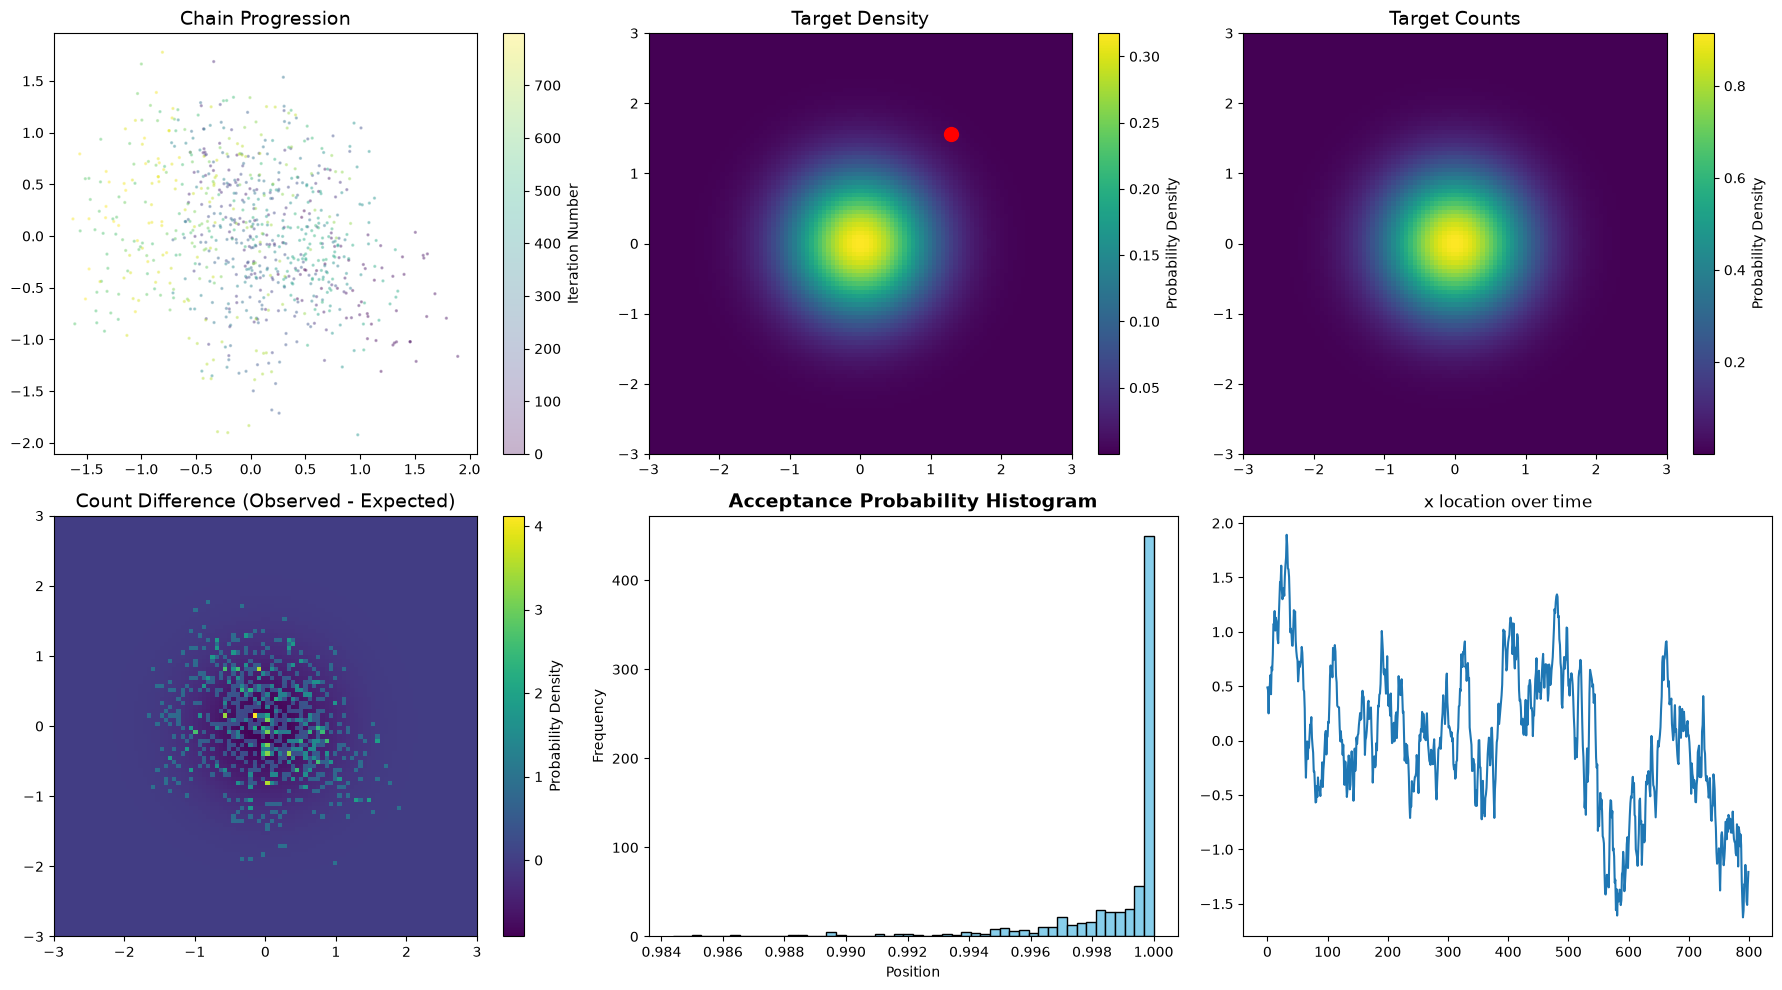

The covariance of the observed points is [[ 0.43496063 -0.09241144]
 [-0.09241144  0.4083371 ]]
KL_divergence is 1.9407267570495605
The KL divergence between a sampled discretized version of the analytical posterior density and the actual analytical posterior density with jitter 0.00125 is 0.008804792538285255
The Hessian used to generate these samples was [[100.   0.]
 [  0.   1.]]


In [30]:

num_good_samples = num_overall_steps - burn_in


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

x_min = -3
x_max = 3
y_min = -3
y_max = 3
n_cells = 100        # number of rectangles per axis
k = 10               # sub-samples per axis per cell (k*k samples per cell)

# cell *edges*, not centers — n_cells rectangles need n_cells+1 boundary points
x_edges = jnp.linspace(x_min, x_max, n_cells + 1)
y_edges = jnp.linspace(y_min, y_max, n_cells + 1)
dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]

# midpoint-rule offsets within a cell, in (0, 1)
offsets = (jnp.arange(k) + 0.5) / k

# fine grid coords: for every cell, k points spread across its interior
x_fine = (x_edges[:-1, None] + offsets[None, :] * dx).ravel()  # shape (n_cells*k,)
y_fine = (y_edges[:-1, None] + offsets[None, :] * dy).ravel()

Xf, Yf = jnp.meshgrid(x_fine, y_fine)
pos_fine = jnp.stack([Xf.ravel(), Yf.ravel()], axis=-1)

Z_fine = jax.vmap(negative_logdensity)(pos_fine)
Z_fine = jnp.exp(-Z_fine).reshape(Xf.shape)          # shape (n_cells*k, n_cells*k)

# block-average: group each k x k sub-block back into one cell and mean it
Z_avg = Z_fine.reshape(n_cells, k, n_cells, k).mean(axis=(1, 3))  # shape (n_cells, n_cells)


total_prob_density = jnp.sum(Z_avg)*(x_max - x_min)*(y_max - y_min)/(n_cells**2)
normalized_density = Z_avg/total_prob_density
expected_bin_prob = normalized_density*(x_max - x_min)*(y_max - y_min)/(n_cells**2)
expected_counts = expected_bin_prob*num_good_samples
observed_counts = jnp.zeros(Z_avg.shape)
x_values = jnp.floor((overall_position_arr[:, 0] - x_min) * n_cells / (x_max - x_min)).astype(int)
y_values = jnp.floor((overall_position_arr[:, 1] - y_min) * n_cells / (y_max - y_min)).astype(int)
observed_counts = observed_counts.at[y_values, x_values].add(1)
observed_bin_prob = observed_counts/num_good_samples

trial_space = jnp.arange(num_overall_steps)
iterations = np.arange(len(overall_position_arr))

scatter2 = axes[0][0].scatter(overall_position_arr[:, 0], overall_position_arr[:, 1], 
                           c=iterations, cmap='viridis', alpha=0.3, s=2)
axes[0][0].set_title("Chain Progression", fontsize=14)
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[0][0], label="Iteration Number") 

heatmap = axes[0][1].imshow(normalized_density, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[0][1].set_title("Target Density", fontsize = 14)
axes[0][1].scatter(hess_x, hess_y, color='red', s=100, zorder=5, label='Hessian Location')
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][1], label='Probability Density')

heatmap = axes[0][2].imshow(expected_counts, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[0][2].set_title("Target Counts", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][2], label='Probability Density')

heatmap = axes[1][0].imshow(observed_counts - expected_counts, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[1][0].set_title("Count Difference (Observed - Expected)", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[1][0], label='Probability Density')

axes[1][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[1][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Position')
axes[1][1].set_ylabel('Frequency')

axes[1][2].plot(iterations, overall_position_arr[:, 0])
axes[1][2].set_title("x location over time")

plt.tight_layout()
plt.show()

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)


chi_2_significance_mask = expected_counts >= 5

important_expected_counts = expected_counts[chi_2_significance_mask]
important_observed_counts = observed_counts[chi_2_significance_mask]
chi_2 = jnp.sum((important_observed_counts - important_expected_counts)**2/important_expected_counts)

cov = jnp.cov(overall_position_arr, rowvar=False)
print(f"The covariance of the observed points is {cov}")
print(f"KL_divergence is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1e-5)}")

linear_probs = normalized_density.ravel();
sampled_analytical_points = jnp.zeros(Z_avg.shape)
random_indices = jr.choice(rng, linear_probs.size, shape = (100000,), replace = True, p = linear_probs)
row_indices, col_indices = jnp.unravel_index(random_indices, normalized_density.shape)
sampled_analytical_points = sampled_analytical_points.at[row_indices, col_indices].add(1)
sampled_analytical_bin_prob = sampled_analytical_points/100000;
jitter = 1/num_good_samples
print(f"The KL divergence between a sampled discretized version of the analytical posterior density and the actual analytical posterior density with jitter {jitter} is {KL_divergence(expected_bin_prob, sampled_analytical_bin_prob, jitter = 1e-5)}")
print(f"The Hessian used to generate these samples was {inv_mass_matrix}")

In [31]:
# compute the average chi^2 using the measurement we took as a baseline
function_output_array = jnp.exp(overall_position_arr[:, 0]) + jnp.exp(overall_position_arr[:, 1])
chi_2_array = ((1 - function_output_array)/measurement_error_bar)**2
print(f"Average Chi^2 statistic based on the measurment: {jnp.average(chi_2_array)}")
# compute the average chi^2 using the prior as a baseline
# the i'th element of chi_2_prior_arr should come out to x^T(C^{-1})x, where x is the i'th row of overall_positon_arr and C is the prior cov matrix
chi_2_prior_array = jnp.sum(overall_position_arr * (overall_position_arr @ inv_prior_cov_matrix), axis=1)
print(f"Average Chi^2 statistic based on the prior: {jnp.average(chi_2_prior_array)}")

Average Chi^2 statistic based on the measurment: 330.8017883300781
Average Chi^2 statistic based on the prior: 0.8427543640136719


In [ ]:
# Animate the first 100 positions! (after the burn in)
overall_exact_position_arr = overall_exact_position_arr.reshape(-1, overall_exact_position_arr.shape[-1])
positions = np.asarray(overall_exact_position_arr[:400, :])
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(8, 6))


heatmap = ax.imshow(normalized_density, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto', alpha = 0.5, zorder = 0)
fig.colorbar(heatmap, ax=ax, label="Density")




ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("HMC Trajectory Animation", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.scatter(hess_x, hess_y, color='red', s=100, zorder=5, label='Hessian Location', alpha = 0.5)
ax.grid(True, linestyle="--", alpha=0.6)

# 3. Initialize plot elements
# 'path' is the fading tail; 'head' is the current position of the sampler
path, = ax.plot([], [], color="blue", alpha=0.5, lw=1.5, label="Trajectory Tail")
head, = ax.plot([], [], color="red", marker="o", markersize=6, label="Current State")
ax.legend(loc="upper right")

# 4. Define the initialization function
def init():
    path.set_data([], [])
    head.set_data([], [])
    return path, head

# 5. Define the update function for each frame
def update(frame):
    # Determine how much history to show in the tail (e.g., last 50 recorded steps)
    tail_length = 50
    start_idx = max(0, frame - tail_length)
    
    # Extract coordinates for the trailing path
    tail_x = positions[start_idx:frame+1, 0]
    tail_y = positions[start_idx:frame+1, 1]
    
    # Extract coordinates for the active head
    current_x = positions[frame, 0]
    current_y = positions[frame, 1]
    
    # Update matplotlib elements (must pass sequences/lists, even for single points)
    path.set_data(tail_x, tail_y)
    head.set_data([current_x], [current_y])
    
    return path, head

# 6. Create the animation
# interval=50 means 50 milliseconds between frames
ani = animation.FuncAnimation(
    fig, update, frames=len(positions), init_func=init, blit=True, interval=50
)

# --- How to View / Save ---

# Choice A: Show it live interactively (Works in standard python scripts or native GUIs)
from IPython.display import HTML
HTML(ani.to_jshtml())